In [1]:
# import libraries
import os
import pandas as pd
import glob
import warnings
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


# define file paths
NEW_LAB_PATH = './model/data/lab/'
OLD_LAB_PATH = './presumed_infection/2.Data/Lab_Test_Results/'
WARD_PATH = './model/data/ward/'
OUTPUT_PATH = './model/output/'
ASE_DEMO_PATH = './presumed_infection/2.Data/Demographics/2022/demographic_ASE_2022.csv'

warnings.filterwarnings("ignore")

In [2]:
# extract 2022 demographic data
# df = pd.read_csv('./presumed_infection/2.Data/Demographics/demographic_SIC_all.csv')
# df[df['Year'] == 2022].to_csv('./presumed_infection/2.Data/Demographics/2022/demographic_SIC_2022.csv', index=False)

In [63]:
# Load existing SIC_data if it exists, otherwise create new
import os

file_path = './model/data/SIC_data.csv'

if os.path.exists(file_path):
    SIC_data = pd.read_csv(file_path)
    print(f"Loaded existing SIC_data with {len(SIC_data)} rows and {len(SIC_data.columns)} columns")
else:
    SIC_data = pd.DataFrame()
    print("Creating new SIC_data file")

# Get demographic data
df = pd.read_csv(ASE_DEMO_PATH)

# Create temporary dataframe for new variables
new_vars = df[['Reference Key', 'HN Number', 'Institution (IPAS)', 'SIC', 'plt_true_date', 
               'Sex', 'Admission Age (Year) (episode based)']].copy()
new_vars = new_vars.drop_duplicates(subset='Reference Key')
new_vars.rename(columns={'Admission Age (Year) (episode based)': 'Age'}, inplace=True)

# If SIC_data already exists, merge on Reference Key
if len(SIC_data) > 0:
    # Keep existing columns, add/update new ones
    for col in ['Reference Key', 'HN Number', 'Institution (IPAS)', 'SIC', 'plt_true_date', 'Sex', 'Age']:
        if col in new_vars.columns and col not in SIC_data.columns:
            # Merge missing columns
            SIC_data = SIC_data.merge(new_vars[['Reference Key', col]], on='Reference Key', how='left')
        elif col in new_vars.columns and col in SIC_data.columns:
            # Update existing column if needed (optional)
            print(f"  Column '{col}' already exists, keeping existing values")
else:
    # New file, use new_vars as base
    SIC_data = new_vars

# Add comorbidity flags (append to existing)
# HTN - hypertension
HTN_keys = df[df['Dx/Px Description (HAMDCT)'].str.contains('hypertension', case=False, na=False)]['Reference Key'].unique()
if 'HTN' not in SIC_data.columns:
    SIC_data['HTN'] = SIC_data['Reference Key'].isin(HTN_keys)
    print("  Added HTN column")
else:
    print("  HTN column already exists, skipping")

# CKD - chronic kidney disease
CKD_keys = df[df['Dx/Px Description (HAMDCT)'].str.contains('chronic kidney disease', case=False, na=False)]['Reference Key'].unique()
if 'CKD' not in SIC_data.columns:
    SIC_data['CKD'] = SIC_data['Reference Key'].isin(CKD_keys)
    print("  Added CKD column")
else:
    print("  CKD column already exists, skipping")

# CA - cancer (dxpx code 140-239)
CA_codes = df[df['Dx/Px code'].astype(str).str.split('.').str[0].str.match(r'^(14[0-9]|1[5-9][0-9]|2[0-3][0-9])')]['Reference Key'].unique()
if 'CA' not in SIC_data.columns:
    SIC_data['CA'] = SIC_data['Reference Key'].isin(CA_codes)
    print("  Added CA column")
else:
    print("  CA column already exists, skipping")

# DM - diabetes mellitus
DM_keys = df[df['Dx/Px Description (HAMDCT)'].str.contains('diabetes mellitus', case=False, na=False)]['Reference Key'].unique()
if 'DM' not in SIC_data.columns:
    SIC_data['DM'] = SIC_data['Reference Key'].isin(DM_keys)
    print("  Added DM column")
else:
    print("  DM column already exists, skipping")

# HLD - hyperlipidemia
HLD_keys = df[df['Dx/Px Description (HAMDCT)'].str.contains('hyperlipidemia', case=False, na=False)]['Reference Key'].unique()
if 'HLD' not in SIC_data.columns:
    SIC_data['HLD'] = SIC_data['Reference Key'].isin(HLD_keys)
    print("  Added HLD column")
else:
    print("  HLD column already exists, skipping")

# HF - heart failure
HF_keys = df[df['Dx/Px Description (HAMDCT)'].str.contains('heart failure|CHF', case=False, na=False)]['Reference Key'].unique()
if 'HF' not in SIC_data.columns:
    SIC_data['HF'] = SIC_data['Reference Key'].isin(HF_keys)
    print("  Added HF column")
else:
    print("  HF column already exists, skipping")

# IHD - ischemic heart disease
IHD_keys = df[df['Dx/Px Description (HAMDCT)'].str.contains('IHD', case=False, na=False)]['Reference Key'].unique()
if 'IHD' not in SIC_data.columns:
    SIC_data['IHD'] = SIC_data['Reference Key'].isin(IHD_keys)
    print("  Added IHD column")
else:
    print("  IHD column already exists, skipping")

# COPD - chronic obstructive pulmonary disease
COPD_keys = df[df['Dx/Px Description (HAMDCT)'].str.contains('COPD', case=False, na=False)]['Reference Key'].unique()
if 'COPD' not in SIC_data.columns:
    SIC_data['COPD'] = SIC_data['Reference Key'].isin(COPD_keys)
    print("  Added COPD column")
else:
    print("  COPD column already exists, skipping")

# Vent - ventilation
Vent_keys = df[df['Dx/Px Description (HAMDCT)'].str.contains('ventilation', case=False, na=False)]['Reference Key'].unique()
if 'Vent' not in SIC_data.columns:
    SIC_data['Vent'] = SIC_data['Reference Key'].isin(Vent_keys)
    print("  Added Vent column")
else:
    print("  Vent column already exists, skipping")

# Save the updated data (append mode)
SIC_data.to_csv(file_path, index=False)
print(f"\n✅ Data saved to {file_path}")
print(f"   Total rows: {len(SIC_data)}")
print(f"   Total columns: {len(SIC_data.columns)}")
print(f"\nColumns in file:")
for col in SIC_data.columns:
    print(f"  - {col}")

Loaded existing SIC_data with 34443 rows and 44 columns
  Column 'Reference Key' already exists, keeping existing values
  Column 'HN Number' already exists, keeping existing values
  Column 'Institution (IPAS)' already exists, keeping existing values
  Column 'SIC' already exists, keeping existing values
  Column 'plt_true_date' already exists, keeping existing values
  Column 'Sex' already exists, keeping existing values
  Column 'Age' already exists, keeping existing values
  HTN column already exists, skipping
  CKD column already exists, skipping
  CA column already exists, skipping
  DM column already exists, skipping
  HLD column already exists, skipping
  HF column already exists, skipping
  IHD column already exists, skipping
  COPD column already exists, skipping
  Vent column already exists, skipping

✅ Data saved to ./model/data/SIC_data.csv
   Total rows: 34443
   Total columns: 44

Columns in file:
  - Reference Key
  - HN Number
  - Institution (IPAS)
  - SIC
  - plt_tru

In [51]:
# save lab data (latest result before SIC onset for SIC patients)
lab_df = pd.read_csv('./model/data/lab/merged_lab_data.csv')
demo_df = pd.read_csv(ASE_DEMO_PATH)
demo_df['Admission Date (yyyy-mm-dd)'] = pd.to_datetime(demo_df['Admission Date (yyyy-mm-dd)'], errors='coerce')
lab_df['LIS Reference Datetime'] = pd.to_datetime(lab_df['LIS Reference Datetime'], errors='coerce')
SIC_data = pd.read_csv('./model/data/SIC_data.csv')

print(f"Processing {len(SIC_data)} patients for lab data extraction...")

def get_latest_lab_before_onset(patient_labs, is_sic_true, plt_true_date, admission_date):
    """
    Get the latest lab result before SIC onset (or latest overall for non-SIC)
    
    Returns:
    - The most recent lab value (single value, not min/max)
    - For SIC = TRUE: latest lab BEFORE plt_true_date
    - For SIC = FALSE: latest lab from admission onwards
    """
    if len(patient_labs) == 0:
        return None
    
    # First filter by admission date
    patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission_date]
    
    if len(patient_labs) == 0:
        return None
    
    if is_sic_true and pd.notna(plt_true_date):
        # Exclude labs on or after plt_true_date
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] < plt_true_date]
    
    if len(patient_labs) == 0:
        return None
    
    # Sort by datetime and get the latest (most recent)
    patient_labs = patient_labs.sort_values('LIS Reference Datetime', ascending=False)
    return patient_labs.iloc[0]['LIS Result: Numeric Result']

# Lym - Lymphocyte (latest)
Lym_data = []
print("Processing Lymphocyte data (latest result)...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    
    ref_key = row['Reference Key']
    admission_dates = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    plt_true_date = row['plt_true_date'] if 'plt_true_date' in row else None
    
    if len(admission_dates) > 0 and pd.notna(admission_dates[0]):
        admission = admission_dates[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        
        # Filter for Lymphocyte tests
        patient_labs = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Lymphocyte', case=False, na=False)]
        
        # Get latest value
        lym_value = get_latest_lab_before_onset(
            patient_labs, 
            row['SIC'], 
            plt_true_date, 
            admission
        )
    else:
        lym_value = None
    Lym_data.append(lym_value)
SIC_data['Lym'] = Lym_data
print("  Completed: Lymphocyte (latest)")

# Hb - Hemoglobin (latest)
HB_data = []
print("Processing Hemoglobin data (latest result)...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    
    ref_key = row['Reference Key']
    admission_dates = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    plt_true_date = row['plt_true_date'] if 'plt_true_date' in row else None
    
    if len(admission_dates) > 0 and pd.notna(admission_dates[0]):
        admission = admission_dates[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        
        # Filter for Hemoglobin tests
        patient_labs = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Haemoglobin', case=False, na=False)]
        
        # Get latest value
        hb_value = get_latest_lab_before_onset(
            patient_labs, 
            row['SIC'], 
            plt_true_date, 
            admission
        )
    else:
        hb_value = None
    HB_data.append(hb_value)
SIC_data['Hb'] = HB_data
print("  Completed: Hemoglobin (latest)")

# PLT - Platelet (latest)
plt_df = pd.read_csv(OLD_LAB_PATH + 'Platelet/2022/plt_2022.csv')
PLT_data = []
print("Processing Platelet data (latest result)...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    
    ref_key = row['Reference Key']
    admission_dates = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    plt_true_date = row['plt_true_date'] if 'plt_true_date' in row else None
    
    if len(admission_dates) > 0 and pd.notna(admission_dates[0]):
        admission = admission_dates[0]
        patient_plts = plt_df[plt_df['Reference Key'] == ref_key].copy()
        if len(patient_plts) > 0:
            patient_plts['LIS Reference Datetime'] = pd.to_datetime(patient_plts['LIS Reference Datetime'])
        
        # Filter for Platelet tests
        patient_plts = patient_plts[patient_plts['LIS Test Description (ePR)'].str.contains('Platelet', case=False, na=False)]
        
        # Get latest value
        plt_value = get_latest_lab_before_onset(
            patient_plts, 
            row['SIC'], 
            plt_true_date, 
            admission
        )
    else:
        plt_value = None
    PLT_data.append(plt_value)
SIC_data['PLT'] = PLT_data
print("  Completed: Platelet (latest)")

# Generic function for latest value extraction
def extract_latest_lab_value(SIC_data, demo_df, lab_df, lab_name, search_pattern, 
                              external_df=None):
    """
    Extract the latest lab value before SIC onset (or latest overall for non-SIC)
    """
    data_list = []
    print(f"Processing {lab_name} data (latest result)...")
    
    for idx, row in SIC_data.iterrows():
        if idx % 1000 == 0 and idx > 0:
            print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
        
        ref_key = row['Reference Key']
        admission_dates = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
        plt_true_date = row['plt_true_date'] if 'plt_true_date' in row else None
        
        if len(admission_dates) > 0 and pd.notna(admission_dates[0]):
            admission = admission_dates[0]
            
            # Use external dataframe if provided
            if external_df is not None:
                patient_data = external_df[external_df['Reference Key'] == ref_key].copy()
                if 'LIS Reference Datetime' in patient_data.columns:
                    patient_data['LIS Reference Datetime'] = pd.to_datetime(patient_data['LIS Reference Datetime'])
            else:
                patient_data = lab_df[lab_df['Reference Key'] == ref_key]
            
            # Filter by test description
            patient_data = patient_data[patient_data['LIS Test Description (ePR)'].str.contains(search_pattern, case=False, na=False)]
            
            # Get latest value before onset
            value = get_latest_lab_before_onset(
                patient_data, 
                row['SIC'], 
                plt_true_date, 
                admission
            )
        else:
            value = None
        data_list.append(value)
    
    SIC_data[lab_name] = data_list
    print(f"  Completed: {lab_name} (latest)")

# Use the generic function for all labs
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'RBC', 'RBC')
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'RDW', 'RDW')
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'K', 'Potassium')
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'Na', 'Sodium')
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'Mg', 'Magnesium')
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'Ca', 'Calcium')
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'Glu', 'Glucose')
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'Alb', 'Albumin')
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'TC', 'Cholesterol')

# Lactate (separate file)
lac_df = pd.read_csv(OLD_LAB_PATH + 'Lactate/2022/lact_2022.csv')
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'Lac', 'Lactate', external_df=lac_df)

# pH
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'pH', r'\bpH\b')

# Fibrinogen
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'FIB', 'Fibrinogen')

# ALT
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'ALT', 'Alanine Aminotransferase')

# AST
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'AST', 'Aspartate Aminotransferase')

# Direct Bilirubin
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'DBil', 'Direct')

# Total Bilirubin (separate file)
bili_df = pd.read_csv(OLD_LAB_PATH + 'Bilirubin/2022/bili_2022.csv')
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'TBil', 'Bilirubin', external_df=bili_df)

# Uric Acid
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'UA', 'Urate')

# NT-proBNP
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'NT-proBNP', 'proBNP')

# Troponin T
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'TNT', 'Troponin T')

# Creatinine (separate file)
crea_df = pd.read_csv(OLD_LAB_PATH + 'Creatinine/2022/crea_2022.csv')
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'Crea', 'Creatinine', external_df=crea_df)

# Bicarbonate
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'HCO3', 'Bicarbonate')

# Phosphate
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'PO4', 'Phosphate')

# Urea
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'Urea', 'Urea')

# Base Excess
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'BE', 'Base Excess')

# APTT
extract_latest_lab_value(SIC_data, demo_df, lab_df, 'APTT', 'APTT')

# Save the updated data
SIC_data.to_csv('./model/data/SIC_data.csv', index=False)
print(f"\nAll lab data saved to SIC_data.csv. Total patients: {len(SIC_data)}")

Processing 34443 patients for lab data extraction...
Processing Lymphocyte data (latest result)...
  Progress: 1000/34443 patients processed
  Progress: 2000/34443 patients processed
  Progress: 3000/34443 patients processed
  Progress: 4000/34443 patients processed
  Progress: 5000/34443 patients processed
  Progress: 6000/34443 patients processed
  Progress: 7000/34443 patients processed
  Progress: 8000/34443 patients processed
  Progress: 9000/34443 patients processed
  Progress: 10000/34443 patients processed
  Progress: 11000/34443 patients processed
  Progress: 12000/34443 patients processed
  Progress: 13000/34443 patients processed
  Progress: 14000/34443 patients processed
  Progress: 15000/34443 patients processed
  Progress: 16000/34443 patients processed
  Progress: 17000/34443 patients processed
  Progress: 18000/34443 patients processed
  Progress: 19000/34443 patients processed
  Progress: 20000/34443 patients processed
  Progress: 21000/34443 patients processed
  Progr

In [ ]:
# # check ICU death within 28d
# demo_df = pd.read_csv('./presumed_infection/2.Data/Demographics/2022/demographic_SIC_2022.csv')
# ward_df = pd.read_csv('./mode/data/ward/ward.csv')
# ward_df['Movement Time'] = pd.to_datetime(ward_df['Movement Time'])
# demo_df['Date of Registered Death'] = pd.to_datetime(demo_df['Date of Registered Death'], errors='coerce')
# demo_df['ICU_death'] = False
# mortality_mask = demo_df['28_day_mortality'] == True # within 28d
    
# for idx, row in demo_df[mortality_mask].iterrows():
#     death_date = row['Date of Registered Death']
#     ref_key = row['Reference Key']
#     if pd.notna(death_date):
#         patient_wards = ward_df[ward_df['Reference Key'] == ref_key].sort_values('Movement Time')
#         icu_pattern = 'icu|intensive care|critical care|micu|sicu|cicu|picu|nicu'
#         icu_mask = patient_wards['Hospitalized Ward Name'].str.contains(icu_pattern, case=False, na=False)
#         icu_periods = []
#         in_icu = False
#         icu_start = None
#         for _, ward_row in patient_wards.iterrows():
#             ward_name = str(ward_row['Hospitalized Ward Name']) if pd.notna(ward_row['Hospitalized Ward Name']) else ''
#             movement_type = ward_row['Movement Type']
#             movement_time = ward_row['Movement Time']
#             is_icu = bool(pd.Series([ward_name]).str.contains(icu_pattern, case=False, na=False).iloc[0])
#             if movement_type == 'A' and is_icu:
#                 in_icu = True
#                 icu_start = movement_time
#             elif movement_type == 'D' and in_icu:
#                 in_icu = False
#                 icu_periods.append((icu_start, movement_time))
#             elif movement_type == 'T' and is_icu and not in_icu:
#                 in_icu = True
#                 icu_start = movement_time
#             elif movement_type == 'O' and in_icu:
#                 in_icu = False
#                 icu_periods.append((icu_start, movement_time))
#             elif movement_type == 'T' and not is_icu and in_icu:
#                 in_icu = False
#                 icu_periods.append((icu_start, movement_time))
#         for start, end in icu_periods:
#             if start <= death_date <= end:
#                 demo_df.at[idx, 'ICU_death'] = True
#                 break

# demo_df.to_csv('./presumed_infection/2.Data/Demographics/2022/demographic_SIC_2022.csv', index=False)

In [34]:
file_path = "./model/data/SIC_data.csv"

# Read the data
df = pd.read_csv(file_path)

# Define the columns to check
columns_to_check = [
    'Lym', 'Hb', 'RBC', 'RDW', 'K', 'Na', 'Mg', 'Ca', 'Glu', 
    'Alb', 'TC', 'Lac', 'pH', 'FIB', 'ALT', 'AST', 'DBil', 'TBil', 'UA', 
    'NT-proBNP', 'TNT', 'Crea', 'HCO3', 'PO4', 'Urea', 'BE', 'APTT'
]

# Function to count non-empty values in a row
def count_non_empty(row):
    count = 0
    for val in row:
        if pd.notna(val) and not (isinstance(val, str) and val.strip() == ''):
            count += 1
    return count

# Filter to keep rows with >3 non-empty columns (i.e., at least 4)
df_filtered = df[df[columns_to_check].apply(count_non_empty, axis=1) > 3]

# Save filtered data
output_path = "./model/data/SIC_data_filtered.csv"
df_filtered.to_csv(output_path, index=False)

print(f"Original rows: {len(df)}")
print(f"Filtered rows (>=4 non-empty columns): {len(df_filtered)}")
print(f"Rows removed: {len(df) - len(df_filtered)}")
print(f"Filtered data saved to: {output_path}")

# Optional: Show distribution of non-empty column counts
non_empty_counts = df[columns_to_check].apply(count_non_empty, axis=1)
print("\nDistribution of non-empty column counts:")
print(non_empty_counts.value_counts().sort_index())

Original rows: 34443
Filtered rows (>=4 non-empty columns): 578
Rows removed: 33865
Filtered data saved to: ./model/data/SIC_data_filtered.csv

Distribution of non-empty column counts:
0      9229
1        51
2     14868
3      9717
10        1
11        4
12        8
13       11
14       32
15       70
16       77
17       92
18      138
19       89
20       35
21       13
22        5
23        1
24        1
25        1
Name: count, dtype: int64


In [53]:
SIC_data = pd.read_csv('./model/data/SIC_data_filtered.csv')
lab_df = pd.read_csv('./model/data/lab/merged_lab_data.csv')

lab_vars = ['Lym', 'Hb', 'PLT', 'RBC', 'RDW', 'K', 'Na', 'Mg', 'Ca', 'Glu', 'Alb', 
            'TC', 'Lac', 'pH', 'FIB', 'ALT', 'AST', 'DBil', 'TBil', 'UA', 'NT-proBNP', 
            'TNT', 'Crea', 'HCO3', 'PO4', 'Urea', 'BE', 'APTT']

# Get keys that exist in lab data
lab_keys = set(lab_df['Reference Key'].astype(str))

# Filter SIC_data to only patients with lab data
SIC_filtered = SIC_data[SIC_data['Reference Key'].astype(str).isin(lab_keys)]
total_lab_patients = len(SIC_filtered)

print(f"Total patients in SIC_data_filtered.csv: {len(SIC_data)}")
print(f"Patients with lab data (in merged_lab_data.csv): {total_lab_patients}")
print("="*60)

for var in lab_vars:
    if var in SIC_data.columns:
        non_null = SIC_filtered[var].notna().sum()
        completeness = (non_null / total_lab_patients) * 100 if total_lab_patients > 0 else 0
        print(f"{var:12} : {non_null:6}/{total_lab_patients} ({completeness:5.1f}%)")
    else:
        print(f"{var:12} : Column not found")

print("="*60)

Total patients in SIC_data_filtered.csv: 578
Patients with lab data (in merged_lab_data.csv): 578
Lym          :    562/578 ( 97.2%)
Hb           :    577/578 ( 99.8%)
PLT          :    577/578 ( 99.8%)
RBC          :    577/578 ( 99.8%)
RDW          :    575/578 ( 99.5%)
K            :    578/578 (100.0%)
Na           :    578/578 (100.0%)
Mg           :    219/578 ( 37.9%)
Ca           :    540/578 ( 93.4%)
Glu          :    348/578 ( 60.2%)
Alb          :    578/578 (100.0%)
TC           :     61/578 ( 10.6%)
Lac          :    256/578 ( 44.3%)
pH           :    409/578 ( 70.8%)
FIB          :     19/578 (  3.3%)
ALT          :    578/578 (100.0%)
AST          :    128/578 ( 22.1%)
DBil         :     17/578 (  2.9%)
TBil         :    578/578 (100.0%)
UA           :     46/578 (  8.0%)
NT-proBNP    :      2/578 (  0.3%)
TNT          :     12/578 (  2.1%)
Crea         :    578/578 (100.0%)
HCO3         :     56/578 (  9.7%)
PO4          :    537/578 ( 92.9%)
Urea         :    578/578 (

In [57]:
SIC_data = pd.read_csv('./model/data/SIC_data_filtered.csv')
demo_df = pd.read_csv(ASE_DEMO_PATH)
demo_df['Admission Date (yyyy-mm-dd)'] = pd.to_datetime(demo_df['Admission Date (yyyy-mm-dd)'], errors='coerce')

SIC_data = SIC_data.merge(demo_df[['Reference Key', 'Admission Date (yyyy-mm-dd)', '7_day_mortality', '28_day_mortality']], on='Reference Key', how='left')
SIC_data = SIC_data.drop_duplicates(subset='Reference Key') # remove dupes

SIC_data['plt_true_date'] = pd.to_datetime(SIC_data['plt_true_date'], errors='coerce')
SIC_data['Admission Date (yyyy-mm-dd)'] = pd.to_datetime(SIC_data['Admission Date (yyyy-mm-dd)'], errors='coerce')

SIC_data['plt_remove'] = False # remove SIC patients with onset within 1 day of admission
mask = (SIC_data['plt_true_date'].notna()) & (SIC_data['Admission Date (yyyy-mm-dd)'].notna())
SIC_data.loc[mask, 'plt_remove'] = (SIC_data.loc[mask, 'plt_true_date'] - SIC_data.loc[mask, 'Admission Date (yyyy-mm-dd)']).dt.days.abs() < 1

SIC_data = SIC_data[~SIC_data['plt_remove']]

SIC_data = SIC_data.drop(columns=['plt_true_date', 'Admission Date (yyyy-mm-dd)'])

lab_vars = ['Lym', 'Hb', 'PLT', 'RBC', 'RDW', 'K', 'Na', 'Mg', 'Ca', 'Glu', 'Alb', 
            'TC', 'Lac', 'pH', 'FIB', 'ALT', 'AST', 'DBil', 'TBil', 'UA', 'NT-proBNP', 
            'TNT', 'Crea', 'HCO3', 'PO4', 'Urea', 'BE', 'APTT']

means_sic_true = SIC_data[SIC_data['SIC'] == True][lab_vars].mean() # replace missing values with group means
means_sic_false = SIC_data[SIC_data['SIC'] == False][lab_vars].mean()

for var in lab_vars:
    if var in SIC_data.columns:
        mask_true = (SIC_data['SIC'] == True) & (SIC_data[var].isna())
        mask_false = (SIC_data['SIC'] == False) & (SIC_data[var].isna())
        SIC_data.loc[mask_true, var] = means_sic_true[var]
        SIC_data.loc[mask_false, var] = means_sic_false[var]

SIC_data = SIC_data.drop(columns=['plt_remove', 'Mg', 'TC', 'FIB', 'AST', 'DBil', 'UA', 'NT-proBNP', 'TNT', 'HCO3', 'Glu', 'Lac']) # >20% missing

SIC_data.to_csv('./model/data/SIC_data_processed.csv', index=False)
print(f"Patients after removal: {len(SIC_data)}")

Patients after removal: 578


In [58]:
file_path = "./model/data/SIC_data_processed.csv"
df = pd.read_csv(file_path)

print("=" * 50)
print("SIC LABEL DISTRIBUTION")
print("=" * 50)

# Check if 'SIC' column exists
if 'SIC' in df.columns:
    sic_counts = df['SIC'].value_counts()
    sic_percentages = df['SIC'].value_counts(normalize=True) * 100
    
    print("\nCounts:")
    for label, count in sic_counts.items():
        print(f"  SIC = {label}: {count:,} rows")
    
    print("\nPercentages:")
    for label, pct in sic_percentages.items():
        print(f"  SIC = {label}: {pct:.1f}%")
    
    print(f"\nTotal rows: {len(df):,}")

SIC LABEL DISTRIBUTION

Counts:
  SIC = False: 465 rows
  SIC = True: 113 rows

Percentages:
  SIC = False: 80.4%
  SIC = True: 19.6%

Total rows: 578


In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score)
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline

# Load data
df = pd.read_csv('./model/data/SIC_data_processed.csv')

# Define features
target = 'SIC'
categorical_features = ['HTN', 'IHD', 'CKD', 'CA', 'HF']
continuous_features = ['Lym', 'RDW', 'K', 'Na', 
                       'Alb', 'ALT', 'TBil', 'Crea', 'PO4', 'Urea', 'APTT', 'BE']
features = continuous_features + categorical_features

# Prepare data
X = df[features].copy()
y = df[target].astype(int)

# Handle missing values
for col in continuous_features:
    X[col] = X[col].fillna(X[col].median())
for col in categorical_features:
    X[col] = X[col].fillna(X[col].mode()[0] if len(X[col].mode()) > 0 else 0)
    if col == 'Sex':
        X[col] = X[col].map({'M': 0, 'F': 1, 'Male': 0, 'Female': 1}).fillna(0)
    else:
        X[col] = X[col].astype(int)

# Get categorical indices for SMOTENC
categorical_indices = [features.index(col) for col in categorical_features]

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Define parameter grids for each model
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'subsample': [0.8, 0.9, 1.0]
    }
}

# Function to find optimal threshold for F1 score
def find_optimal_threshold(y_true, y_proba, thresholds=None):
    """
    Find optimal threshold to maximize F1 score.
    """
    if thresholds is None:
        thresholds = np.arange(0.1, 0.9, 0.01)
    
    best_threshold = 0.5
    best_f1 = 0
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    return best_threshold, best_f1

# Cross-validation
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results = []

for name in models.keys():
    print(f"\n{'='*60}")
    print(f"Tuning {name}...")
    print(f"{'='*60}")
    
    auc_scores, acc_scores, prec_scores, rec_scores, f1_scores = [], [], [], [], []
    opt_thresholds = []
    best_params_list = []
    
    fold = 1
    for train_idx, val_idx in cv_outer.split(X, y):
        print(f"  Fold {fold}/5")
        
        # Split
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Scale continuous features
        scaler = StandardScaler()
        X_train_cont = scaler.fit_transform(X_train[continuous_features])
        X_val_cont = scaler.transform(X_val[continuous_features])
        
        # Combine with categorical
        X_train_combined = np.hstack([X_train_cont, X_train[categorical_features].values])
        X_val_combined = np.hstack([X_val_cont, X_val[categorical_features].values])
        
        # Create pipeline with SMOTENC and model
        pipeline = Pipeline([
            ('smotenc', SMOTENC(categorical_features=categorical_indices, random_state=42)),
            ('classifier', models[name])
        ])
        
        # Grid search with inner CV
        grid_search = GridSearchCV(
            pipeline, 
            param_grid={f'classifier__{k}': v for k, v in param_grids[name].items()},
            cv=cv_inner, 
            scoring='roc_auc',
            n_jobs=-1,
            verbose=0
        )
        
        # Fit grid search
        grid_search.fit(X_train_combined, y_train)
        
        # Get best model
        best_model = grid_search.best_estimator_
        best_params_list.append(grid_search.best_params_)
        
        # Predict probabilities on validation set
        y_pred_proba = best_model.predict_proba(X_val_combined)[:, 1]
        
        # Find optimal threshold for F1 score
        optimal_threshold, best_f1 = find_optimal_threshold(y_val, y_pred_proba)
        opt_thresholds.append(optimal_threshold)
        
        # Make predictions with optimal threshold
        y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
        
        # Calculate metrics
        auc_scores.append(roc_auc_score(y_val, y_pred_proba))
        acc_scores.append(accuracy_score(y_val, y_pred_optimal))
        prec_scores.append(precision_score(y_val, y_pred_optimal, zero_division=0))
        rec_scores.append(recall_score(y_val, y_pred_optimal))
        f1_scores.append(f1_score(y_val, y_pred_optimal, zero_division=0))
        
        print(f"    Best params: {grid_search.best_params_}")
        print(f"    Optimal threshold: {optimal_threshold:.3f} (best F1: {best_f1:.4f})")
        print(f"    Val AUC: {auc_scores[-1]:.4f}")
        fold += 1
    
    # Get most common best parameters
    best_params_summary = {}
    for params in best_params_list:
        for k, v in params.items():
            if k not in best_params_summary:
                best_params_summary[k] = []
            best_params_summary[k].append(v)
    
    print(f"\n  {name} - Cross-validation results:")
    print(f"    AUC: {np.mean(auc_scores):.4f} (±{np.std(auc_scores):.4f})")
    print(f"    Accuracy: {np.mean(acc_scores):.4f} (±{np.std(acc_scores):.4f})")
    print(f"    Precision: {np.mean(prec_scores):.4f} (±{np.std(prec_scores):.4f})")
    print(f"    Recall: {np.mean(rec_scores):.4f} (±{np.std(rec_scores):.4f})")
    print(f"    F1: {np.mean(f1_scores):.4f} (±{np.std(f1_scores):.4f})")
    print(f"    Optimal threshold: {np.mean(opt_thresholds):.3f} (±{np.std(opt_thresholds):.3f})")
    
    results.append({
        'Model': name,
        'AUC_Mean': np.mean(auc_scores), 
        'AUC_Std': np.std(auc_scores),
        'Accuracy_Mean': np.mean(acc_scores), 
        'Accuracy_Std': np.std(acc_scores),
        'Precision_Mean': np.mean(prec_scores), 
        'Precision_Std': np.std(prec_scores),
        'Recall_Mean': np.mean(rec_scores), 
        'Recall_Std': np.std(rec_scores),
        'F1_Mean': np.mean(f1_scores), 
        'F1_Std': np.std(f1_scores),
        'Optimal_Threshold_Mean': np.mean(opt_thresholds),
        'Optimal_Threshold_Std': np.std(opt_thresholds),
        'Best_Params': str(dict((k, max(set(v), key=v.count)) for k, v in best_params_summary.items()))
    })

# Display results
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("LOGISTIC REGRESSION, RANDOM FOREST & GRADIENT BOOSTING")
print("5-FOLD CROSS-VALIDATION RESULTS WITH F1 THRESHOLD OPTIMIZATION")
print("="*80)
print(results_df[['Model', 'AUC_Mean', 'AUC_Std', 'Accuracy_Mean', 'Precision_Mean', 
                  'Recall_Mean', 'F1_Mean', 'Optimal_Threshold_Mean']].round(4).to_string(index=False))

# Best model
print("\n" + "="*80)
print("BEST MODEL:")
print("="*80)
best_idx = results_df['F1_Mean'].idxmax()
best_model = results_df.loc[best_idx]

print(f"\nBest Model: {best_model['Model']}")
print(f"  F1 Score: {best_model['F1_Mean']:.4f} (±{best_model['F1_Std']:.4f})")
print(f"  AUC: {best_model['AUC_Mean']:.4f} (±{best_model['AUC_Std']:.4f})")
print(f"  Accuracy: {best_model['Accuracy_Mean']:.4f}")
print(f"  Precision: {best_model['Precision_Mean']:.4f}")
print(f"  Recall: {best_model['Recall_Mean']:.4f}")
print(f"  Optimal Threshold: {best_model['Optimal_Threshold_Mean']:.3f}")
print(f"  Best Parameters: {best_model['Best_Params']}")

# Save results
results_df.to_csv('./model/results_lr_rf_gb_f1_optimized.csv', index=False)
print("\nResults saved to: ./model/results_lr_rf_gb_f1_optimized.csv")
print("="*80)


Tuning Logistic Regression...
  Fold 1/5
    Best params: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
    Optimal threshold: 0.590 (best F1: 0.4762)
    Val AUC: 0.6704
  Fold 2/5
    Best params: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
    Optimal threshold: 0.570 (best F1: 0.4082)
    Val AUC: 0.6265
  Fold 3/5
    Best params: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
    Optimal threshold: 0.520 (best F1: 0.4932)
    Val AUC: 0.7359
  Fold 4/5
    Best params: {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
    Optimal threshold: 0.540 (best F1: 0.3934)
    Val AUC: 0.6114
  Fold 5/5
    Best params: {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
    Optimal threshold: 0.590 (best F1: 0.5333)
    Val AUC: 0.6911

  Logistic Regression - Cross-validation results:
    AUC: 0.6671 (±0.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, roc_curve)
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline

# LightGBM and XGBoost
import lightgbm as lgb
import xgboost as xgb

# Load data
df = pd.read_csv('./model/data/SIC_data_processed.csv')

# Define features
target = 'SIC'
categorical_features = ['HTN', 'IHD', 'CKD', 'CA', 'HF']
continuous_features = ['Lym', 'RDW', 'K', 'Na', 
                       'Alb', 'ALT', 'TBil', 'Crea', 'PO4', 'Urea', 'APTT', 'BE']
features = continuous_features + categorical_features

# Prepare data
X = df[features].copy()
y = df[target].astype(int)

# Handle missing values
for col in continuous_features:
    X[col] = X[col].fillna(X[col].median())
for col in categorical_features:
    X[col] = X[col].fillna(X[col].mode()[0] if len(X[col].mode()) > 0 else 0)
    X[col] = X[col].astype(int)

# Get categorical indices for SMOTENC
categorical_indices = [features.index(col) for col in categorical_features]

# Define models
models = {
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1),
    'XGBoost': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Define parameter grids for each model
param_grids = {
    'LightGBM': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [15, 31, 63],
        'min_child_samples': [5, 10, 20],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
    },
    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'gamma': [0, 0.1, 0.2],
        'reg_alpha': [0, 0.1, 1],
        'reg_lambda': [1, 1.5, 2]
    }
}

# Function to find optimal threshold for F1 score
def find_optimal_threshold(y_true, y_proba, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.1, 0.9, 0.01)
    
    best_threshold = 0.5
    best_f1 = 0
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    return best_threshold, best_f1

# Cross-validation
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results = []
best_model_final = None
best_scaler_final = None
best_threshold_final = 0.5

for name in models.keys():
    print(f"\n{'='*60}")
    print(f"Tuning {name}...")
    print(f"{'='*60}")
    
    auc_scores, acc_scores, prec_scores, rec_scores, f1_scores = [], [], [], [], []
    opt_thresholds = []
    best_params_list = []
    
    fold = 1
    for train_idx, val_idx in cv_outer.split(X, y):
        print(f"  Fold {fold}/5")
        
        # Split
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Scale continuous features
        scaler = StandardScaler()
        X_train_cont = scaler.fit_transform(X_train[continuous_features])
        X_val_cont = scaler.transform(X_val[continuous_features])
        
        # Combine with categorical
        X_train_combined = np.hstack([X_train_cont, X_train[categorical_features].values])
        X_val_combined = np.hstack([X_val_cont, X_val[categorical_features].values])
        
        # Create pipeline with SMOTENC and model
        pipeline = Pipeline([
            ('smotenc', SMOTENC(categorical_features=categorical_indices, random_state=42)),
            ('classifier', models[name])
        ])
        
        # Grid search with inner CV
        grid_search = GridSearchCV(
            pipeline, 
            param_grid={f'classifier__{k}': v for k, v in param_grids[name].items()},
            cv=cv_inner, 
            scoring='roc_auc',
            n_jobs=-1,
            verbose=0
        )
        
        # Fit grid search
        grid_search.fit(X_train_combined, y_train)
        
        # Get best model
        best_model = grid_search.best_estimator_
        best_params_list.append(grid_search.best_params_)
        
        # Predict probabilities on validation set
        y_pred_proba = best_model.predict_proba(X_val_combined)[:, 1]
        
        # Find optimal threshold for F1 score
        optimal_threshold, best_f1 = find_optimal_threshold(y_val, y_pred_proba)
        opt_thresholds.append(optimal_threshold)
        
        # Make predictions with optimal threshold
        y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
        
        # Calculate metrics
        auc_scores.append(roc_auc_score(y_val, y_pred_proba))
        acc_scores.append(accuracy_score(y_val, y_pred_optimal))
        prec_scores.append(precision_score(y_val, y_pred_optimal, zero_division=0))
        rec_scores.append(recall_score(y_val, y_pred_optimal))
        f1_scores.append(f1_score(y_val, y_pred_optimal, zero_division=0))
        
        print(f"    Best params: {grid_search.best_params_}")
        print(f"    Optimal threshold: {optimal_threshold:.3f} (best F1: {best_f1:.4f})")
        print(f"    Val AUC: {auc_scores[-1]:.4f}")
        fold += 1
    
    # Get most common best parameters
    best_params_summary = {}
    for params in best_params_list:
        for k, v in params.items():
            if k not in best_params_summary:
                best_params_summary[k] = []
            best_params_summary[k].append(v)
    
    print(f"\n  {name} - Cross-validation results:")
    print(f"    AUC: {np.mean(auc_scores):.4f} (±{np.std(auc_scores):.4f})")
    print(f"    Accuracy: {np.mean(acc_scores):.4f} (±{np.std(acc_scores):.4f})")
    print(f"    Precision: {np.mean(prec_scores):.4f} (±{np.std(prec_scores):.4f})")
    print(f"    Recall: {np.mean(rec_scores):.4f} (±{np.std(rec_scores):.4f})")
    print(f"    F1: {np.mean(f1_scores):.4f} (±{np.std(f1_scores):.4f})")
    print(f"    Optimal threshold: {np.mean(opt_thresholds):.3f} (±{np.std(opt_thresholds):.3f})")
    
    results.append({
        'Model': name,
        'AUC_Mean': np.mean(auc_scores), 
        'AUC_Std': np.std(auc_scores),
        'Accuracy_Mean': np.mean(acc_scores), 
        'Accuracy_Std': np.std(acc_scores),
        'Precision_Mean': np.mean(prec_scores), 
        'Precision_Std': np.std(prec_scores),
        'Recall_Mean': np.mean(rec_scores), 
        'Recall_Std': np.std(rec_scores),
        'F1_Mean': np.mean(f1_scores), 
        'F1_Std': np.std(f1_scores),
        'Optimal_Threshold_Mean': np.mean(opt_thresholds),
        'Optimal_Threshold_Std': np.std(opt_thresholds),
        'Best_Params': str(dict((k, max(set(v), key=v.count)) for k, v in best_params_summary.items()))
    })

# Display results
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("LIGHTGBM & XGBOOST - 5-FOLD CROSS-VALIDATION RESULTS WITH F1 THRESHOLD OPTIMIZATION")
print("="*80)
print(results_df[['Model', 'AUC_Mean', 'AUC_Std', 'Accuracy_Mean', 'Precision_Mean', 
                  'Recall_Mean', 'F1_Mean', 'Optimal_Threshold_Mean']].round(4).to_string(index=False))

# Best model
print("\n" + "="*80)
print("BEST MODEL:")
print("="*80)
best_idx = results_df['F1_Mean'].idxmax()
best_model_info = results_df.loc[best_idx]

print(f"\nBest Model: {best_model_info['Model']}")
print(f"  F1 Score: {best_model_info['F1_Mean']:.4f} (±{best_model_info['F1_Std']:.4f})")
print(f"  AUC: {best_model_info['AUC_Mean']:.4f} (±{best_model_info['AUC_Std']:.4f})")
print(f"  Accuracy: {best_model_info['Accuracy_Mean']:.4f}")
print(f"  Precision: {best_model_info['Precision_Mean']:.4f}")
print(f"  Recall: {best_model_info['Recall_Mean']:.4f}")
print(f"  Optimal Threshold: {best_model_info['Optimal_Threshold_Mean']:.3f}")
print(f"  Best Parameters: {best_model_info['Best_Params']}")

# ============================================================
# TRAIN FINAL BEST MODEL (LightGBM) ON FULL DATA FOR SHAP
# ============================================================
print("\n" + "="*80)
print("TRAINING FINAL BEST MODEL ON FULL DATASET FOR SHAP ANALYSIS")
print("="*80)

# Get best parameters for LightGBM
best_params_str = best_model_info['Best_Params']
import ast
best_params = ast.literal_eval(best_params_str)
# Remove 'classifier__' prefix
best_params_clean = {k.replace('classifier__', ''): v for k, v in best_params.items()}

print(f"Best parameters: {best_params_clean}")

# Scale full dataset
scaler_full = StandardScaler()
X_cont_full = scaler_full.fit_transform(X[continuous_features])
X_full_combined = np.hstack([X_cont_full, X[categorical_features].values])

# Apply SMOTENC on full training data
smotenc_full = SMOTENC(categorical_features=categorical_indices, random_state=42)
X_full_resampled, y_full_resampled = smotenc_full.fit_resample(X_full_combined, y)

# Train final model
final_model = lgb.LGBMClassifier(**best_params_clean, random_state=42, verbose=-1)
final_model.fit(X_full_resampled, y_full_resampled)

# Predict on original data (not resampled) using optimal threshold
y_pred_proba_full = final_model.predict_proba(X_full_combined)[:, 1]
optimal_threshold = best_model_info['Optimal_Threshold_Mean']
y_pred_full = (y_pred_proba_full >= optimal_threshold).astype(int)

# Final metrics
print(f"\nFinal Model Performance on Full Dataset:")
print(f"  AUROC: {roc_auc_score(y, y_pred_proba_full):.4f}")
print(f"  F1 Score: {f1_score(y, y_pred_full):.4f}")
print(f"  Recall: {recall_score(y, y_pred_full):.4f}")
print(f"  Precision: {precision_score(y, y_pred_full):.4f}")

# Confusion Matrix
cm = confusion_matrix(y, y_pred_full)
print(f"\nConfusion Matrix:")
print(f"  TN: {cm[0,0]:4d}   FP: {cm[0,1]:4d}")
print(f"  FN: {cm[1,0]:4d}   TP: {cm[1,1]:4d}")

# ============================================================
# SHAP ANALYSIS FOR FINAL BEST MODEL
# ============================================================
print("\n" + "="*80)
print("GENERATING SHAP PLOTS FOR FINAL BEST MODEL")
print("="*80)

# Create TreeExplainer (fast for tree-based models)
explainer = shap.TreeExplainer(final_model)

# Use original combined data for SHAP (not resampled)
shap_values = explainer.shap_values(X_full_combined)

# Handle binary classification output
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]  # For positive class
    expected_value = explainer.expected_value[1]
else:
    shap_values_class1 = shap_values
    expected_value = explainer.expected_value

# SHAP Summary Plot (beeswarm) - all features
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_class1, X_full_combined, feature_names=features, show=False)
plt.tight_layout()
plt.savefig('./model/shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.close()
print("Saved: shap_summary_plot.png")

# SHAP Bar Plot (mean absolute SHAP values)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_class1, X_full_combined, feature_names=features, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('./model/shap_bar_plot.png', dpi=300, bbox_inches='tight')
plt.close()
print("Saved: shap_bar_plot.png")

# SHAP Waterfall Plot (first positive patient)
positive_indices = np.where(y == 1)[0]
if len(positive_indices) > 0:
    idx = positive_indices[0]
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap.Explanation(
        values=shap_values_class1[idx],
        base_values=expected_value,
        data=X_full_combined[idx],
        feature_names=features
    ), show=False)
    plt.tight_layout()
    plt.savefig('./model/shap_waterfall_plot.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("Saved: shap_waterfall_plot.png")

# Feature Importance (built-in LightGBM)
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances (LightGBM)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('./model/feature_importance.png', dpi=300, bbox_inches='tight')
plt.close()
print("Saved: feature_importance.png")

# ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y, y_pred_proba_full)
plt.plot(fpr, tpr, linewidth=2, label=f'LightGBM (AUC = {roc_auc_score(y, y_pred_proba_full):.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - LightGBM Model', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./model/roc_curve_lightgbm.png', dpi=300)
plt.close()
print("Saved: roc_curve_lightgbm.png")

print("\n" + "="*80)
print("All plots saved to ./model/ directory")
print("="*80)

# Save results
results_df.to_csv('./model/results_lightgbm_xgboost_f1_optimized.csv', index=False)
print("\nResults saved to: ./model/results_lightgbm_xgboost_f1_optimized.csv")
print("="*80)


Tuning LightGBM...
  Fold 1/5
    Best params: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 7, 'classifier__min_child_samples': 20, 'classifier__n_estimators': 200, 'classifier__num_leaves': 15, 'classifier__subsample': 0.7}
    Optimal threshold: 0.820 (best F1: 0.5455)
    Val AUC: 0.7317
  Fold 2/5
    Best params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 10, 'classifier__min_child_samples': 20, 'classifier__n_estimators': 100, 'classifier__num_leaves': 31, 'classifier__subsample': 0.7}
    Optimal threshold: 0.510 (best F1: 0.5909)
    Val AUC: 0.8125
  Fold 3/5
    Best params: {'classifier__colsample_bytree': 0.7, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 10, 'classifier__min_child_samples': 20, 'classifier__n_estimators': 50, 'classifier__num_leaves': 15, 'classifier__subsample': 0.7}
    Optimal threshold: 0.360 (best F1: 0.5946)
    Val AUC: 0.8429
  

DATA QUALITY CHECK
Original dataset shape: (578, 44)
Missing values per column:
NT-proBNP        99.653979
TNT              97.923875
DBil             97.058824
FIB              96.712803
UA               92.041522
HCO3             90.311419
TC               89.446367
plt_true_date    80.449827
AST              77.854671
Mg               62.110727
Lac              55.709343
Glu              39.792388
BE               29.238754
pH               29.238754
APTT              9.861592
PO4               7.093426
Ca                6.574394
Lym               2.768166
RDW               0.519031
RBC               0.173010
Hb                0.173010
PLT               0.173010
dtype: float64

Keeping 28 variables with <50% missing
OUTCOME: SIC
Prevalence: 19.55% (113/578)

Continuous Variables:
Variable         SIC=0         SIC=1  P-value
     Age   76.88±16.23   76.93±15.87   0.9182
     Lym     0.84±3.13     0.71±0.69   0.1199
      Hb     8.93±2.18     9.47±2.45   0.0331
     RBC     3.07±0.77

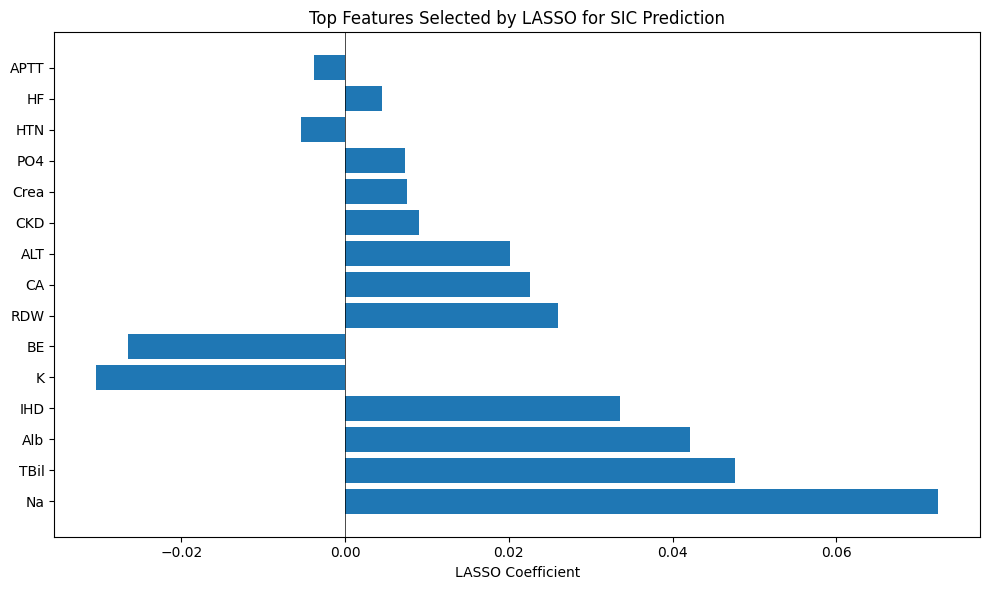


Results saved to ./model/data/lasso_selected_features_SIC.csv


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LassoCV, Lasso
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('./model/data/SIC_data_filtered.csv')

# Check missingness first
print("="*80)
print("DATA QUALITY CHECK")
print("="*80)
print(f"Original dataset shape: {df.shape}")
print(f"Missing values per column:")
missing_pct = df.isnull().mean() * 100
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

# Variables (remove high-missing ones first)
all_vars = ['Sex', 'Age', 'HTN', 'CKD', 'CA', 'DM', 'HLD', 'HF', 'IHD', 'COPD', 'Vent',
            'Lym', 'Hb', 'RBC', 'RDW', 'K', 'Na', 'Mg', 'Ca', 'Glu', 'Alb', 'TC',
            'Lac', 'pH', 'FIB', 'ALT', 'AST', 'DBil', 'TBil', 'UA', 'NT-proBNP', 'TNT',
            'Crea', 'HCO3', 'PO4', 'Urea', 'BE', 'APTT']

# Keep only columns with <50% missing
keep_vars = [v for v in all_vars if v in df.columns and df[v].isnull().mean() < 0.5]
print(f"\nKeeping {len(keep_vars)} variables with <50% missing")

outcome = 'SIC'

# Descriptive stats (don't drop all missing, just per variable)
print("="*80)
print(f"OUTCOME: {outcome}")
print(f"Prevalence: {df[outcome].mean():.2%} ({df[outcome].sum()}/{len(df)})")

# Continuous variables comparison (pairwise deletion)
cont_vars = [v for v in keep_vars if v not in ['Sex', 'HTN', 'CKD', 'CA', 'DM', 'HLD', 'HF', 'IHD', 'COPD', 'Vent']]
results = []
for var in cont_vars:
    group0 = df[df[outcome] == 0][var].dropna()
    group1 = df[df[outcome] == 1][var].dropna()
    if len(group0) > 5 and len(group1) > 5:  # Need at least 5 samples
        stat, p_value = stats.mannwhitneyu(group0, group1, alternative='two-sided')
        results.append({
            'Variable': var,
            'SIC=0': f"{group0.mean():.2f}±{group0.std():.2f}",
            'SIC=1': f"{group1.mean():.2f}±{group1.std():.2f}",
            'P-value': p_value
        })

print("\nContinuous Variables:")
print(pd.DataFrame(results).round(4).to_string(index=False))

# LASSO feature selection - use only complete cases
X = df[keep_vars].copy()
y = df[outcome].copy()

# For LASSO, we need complete rows or imputation
# Option 1: Use only complete rows
complete_mask = ~(X.isnull().any(axis=1) | y.isnull())
X_complete = X[complete_mask]
y_complete = y[complete_mask]

print(f"\nComplete cases for LASSO: {len(X_complete)}/{len(df)} ({len(X_complete)/len(df)*100:.1f}%)")

if len(X_complete) > 50:
    # Prepare data
    X_encoded = pd.get_dummies(X_complete, columns=['Sex'], drop_first=True)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_encoded)
    
    # LASSO CV
    lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
    lasso_cv.fit(X_scaled, y_complete)
    
    # Selected features
    lasso = Lasso(alpha=lasso_cv.alpha_, random_state=42, max_iter=10000)
    lasso.fit(X_scaled, y_complete)
    
    selected = pd.DataFrame({
        'Feature': X_encoded.columns,
        'Coefficient': lasso.coef_
    })
    selected = selected[selected['Coefficient'] != 0].sort_values('Coefficient', key=abs, ascending=False)
    
    print(f"\nLASSO Results (alpha={lasso_cv.alpha_:.4f}):")
    print(f"Selected {len(selected)} features:")
    print(selected.to_string(index=False))
    
    # Plot
    if len(selected) > 0:
        plt.figure(figsize=(10, 6))
        top_n = min(15, len(selected))
        plt.barh(selected['Feature'][:top_n], selected['Coefficient'][:top_n])
        plt.xlabel('LASSO Coefficient')
        plt.title('Top Features Selected by LASSO for SIC Prediction')
        plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        plt.tight_layout()
        plt.savefig('./model/data/lasso_sic_features.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Save results
        selected.to_csv('./model/data/lasso_selected_features_SIC.csv', index=False)
        print(f"\nResults saved to ./model/data/lasso_selected_features_SIC.csv")
    else:
        print("\nNo features selected by LASSO")
else:
    print("\nNot enough complete cases for LASSO. Try imputation or use fewer features.")
    
    # Alternative: Use median imputation
    print("\nTrying with median imputation...")
    X_imputed = X.fillna(X.median())
    X_encoded = pd.get_dummies(X_imputed, columns=['Sex'], drop_first=True)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_encoded)
    
    lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
    lasso_cv.fit(X_scaled, y)
    
    lasso = Lasso(alpha=lasso_cv.alpha_, random_state=42, max_iter=10000)
    lasso.fit(X_scaled, y)
    
    selected = pd.DataFrame({
        'Feature': X_encoded.columns,
        'Coefficient': lasso.coef_
    })
    selected = selected[selected['Coefficient'] != 0].sort_values('Coefficient', key=abs, ascending=False)
    
    print(f"Selected {len(selected)} features (with imputation):")
    print(selected.to_string(index=False))
    selected.to_csv('./model/data/lasso_selected_features_SIC.csv', index=False)